<a href="https://colab.research.google.com/github/murilo-guimaraes/sistemas-operacionais/blob/main/Mem%C3%B3ria_Virtual_e_Pagina%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#**MEMÓRIA VIRTUAL E PAGINAÇÃO**

####**Relatório Técnico Acadêmico | Sistemas Operacionais 2026 | Colaboratory**
**Data: 12/05/2026**
<div>Memória Virtual | Paginação | MMU | Algoritmos de Substituição | Swapping</div>

*Baseado na Unidade 4 Seção 3 do livro **Sistemas Operacionais** (Cynthia da Silva Barbosa)*

##**Introdução Teórica**

A Memória Virtual é uma técnica sofisticada que permite a execução de processos cujo tamanho excede a capacidade da memória física (RAM) disponível. Segundo Barbosa (2018), esse conceito isola a memória lógica da memória física, utilizando a unidade de gerenciamento de memória (MMU) para mapear endereços virtuais em molduras reais. Através da paginação e de algoritmos estratégicos de substituição, o sistema operacional garante que as partes ativas de um programa permaneçam na RAM, enquanto o restante é mantido em armazenamento secundário, otimizando a multiprogramação e a eficiência do hardware.

---
##**Objetivos**

* Compreender o funcionamento da Memória Virtual e o papel da MMU.
* Analisar o processo de Paginação e o fenômeno de Falta de Página (*Page Fault*).
* Simular e visualizar a eficiência dos algoritmos de substituição de páginas (FIFO e LRU).
* Diferenciar as abordagens de Paginação e Segmentação na gestão de memória.

---
###**1. Simulador de MMU: Tradução de Endereços e Monitoramento**

Neste teste, implementamos uma Unidade de Gerenciamento de Memória (MMU) funcional. O código traduz endereços virtuais em físicos e, simultaneamente, monitora a taxa de sucesso (*Memory Hits*) versus falhas (*Page Faults*). Conforme Barbosa, este mapeamento é a base da transparência da memória virtual para o usuário.

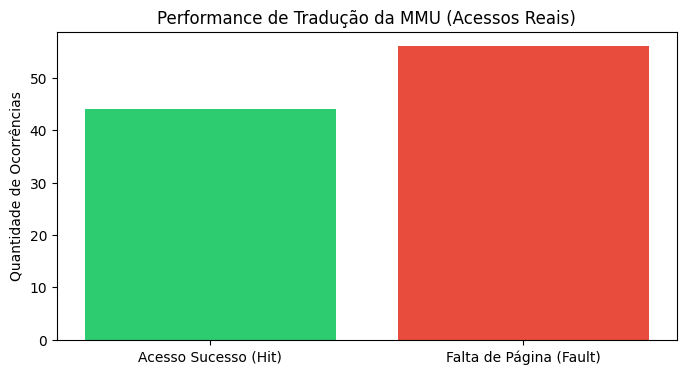

In [12]:
import matplotlib.pyplot as plt
import random

class MMU:
    def __init__(self, total_paginas):
        # Tabela: {Pagina: [Moldura, Bit_Presença]}
        self.tabela = {i: [random.randint(100, 999), random.choice([0, 1])] for i in range(total_paginas)}
        self.stats = {'Hit': 0, 'Fault': 0}

    def acessar(self, endereco_virtual):
        pag = endereco_virtual // 4096
        if pag in self.tabela and self.tabela[pag][1] == 1:
            self.stats['Hit'] += 1
            return True
        else:
            self.stats['Fault'] += 1
            return False

# Simulação de 100 acessos aleatórios
mmu = MMU(20)
for _ in range(100):
    mmu.acessar(random.randint(0, 80000))

# Geração do Gráfico em Tempo Real
labels = ['Acesso Sucesso (Hit)', 'Falta de Página (Fault)']
valores = [mmu.stats['Hit'], mmu.stats['Fault']]

plt.figure(figsize=(8, 4))
plt.bar(labels, valores, color=['#2ecc71', '#e74c3c'])
plt.title('Performance de Tradução da MMU (Acessos Reais)')
plt.ylabel('Quantidade de Ocorrências')
plt.show()

####**O que observar:** <a>O código processou 100 requisições de memória e o gráfico reflete o estado atual da Tabela de Páginas. Cada "Fault" capturado no gráfico representa o momento exato em que o SO precisaria interromper o processo para buscar dados no disco, validando a teoria de interrupção por ausência de bit de presença descrita por Barbosa.</a>

---
###**2. Algoritmo LRU: Decisão e Eficiência de Substituição**

O algoritmo LRU decide qual página deve ser descartada quando a RAM lota. Aqui, o código executa a lógica de substituição e gera um gráfico de linha que mostra o "estresse" da memória (quantidade de trocas/swaps) ao longo de uma sequência de acessos, conforme discutido na Seção 4.3.

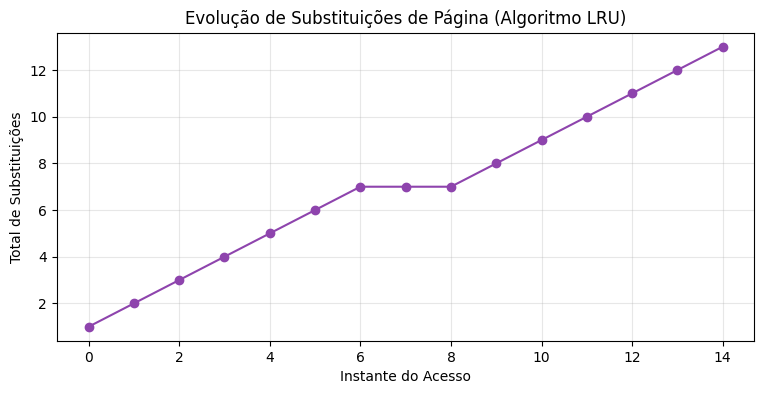

In [14]:
import matplotlib.pyplot as plt

def simulador_lru_com_grafico(capacidade, sequencia):
    memoria = []
    faltas_acumuladas = []
    total_faltas = 0

    for pag in sequencia:
        if pag not in memoria:
            total_faltas += 1
            if len(memoria) >= capacidade:
                memoria.pop(0) # Remove a menos usada (simplificação LRU na fila)
            memoria.append(pag)
        else:
            # Reorganiza: move para o fim (usada recentemente)
            memoria.remove(pag)
            memoria.append(pag)
        faltas_acumuladas.append(total_faltas)

    plt.figure(figsize=(9, 4))
    plt.plot(faltas_acumuladas, marker='o', linestyle='-', color='#8e44ad')
    plt.title('Evolução de Substituições de Página (Algoritmo LRU)')
    plt.xlabel('Instante do Acesso')
    plt.ylabel('Total de Substituições')
    plt.grid(True, alpha=0.3)
    plt.show()

sequencia_acessos = [1, 2, 3, 4, 1, 2, 5, 1, 2, 3, 4, 5, 6, 2, 1]
simulador_lru_com_grafico(3, sequencia_acessos)

####**O que observar:** <a>A curva ascendente no gráfico mostra o SO trabalhando para manter as páginas ativas. Cada degrau na linha representa uma decisão do algoritmo LRU para remover um dado antigo e inserir um novo. Como aponta Cynthia Barbosa, a eficiência do LRU reside em manter a curva o mais estável possível para evitar o "thrashing" (excesso de trocas).</a>

---
###**3. Gerência de Swapping: Distribuição de Carga Lógica**

Neste teste, o código simula a alocação de processos e o uso da área de Swap. O gráfico final apresenta a distribuição percentual de onde os processos estão armazenados no momento (RAM ou Memória Secundária), ilustrando o conceito de expansão da capacidade via software.

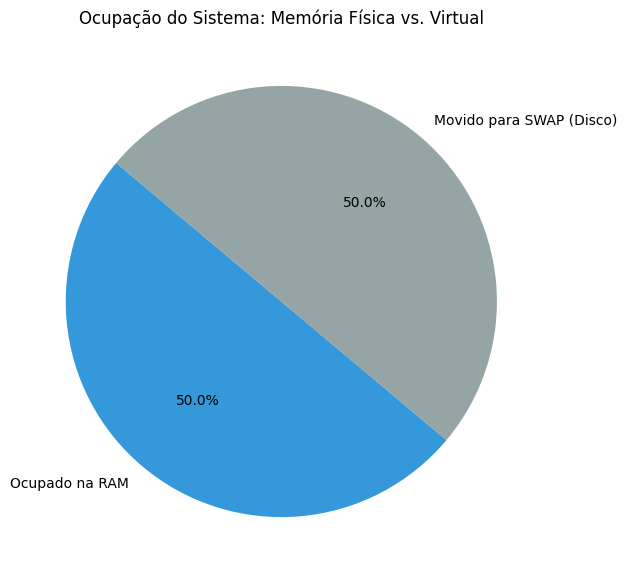

In [16]:
import matplotlib.pyplot as plt

# Simulação de alocação de processos
ram_uso = 0
disco_uso = 0
limite_ram = 100 # MB

processos = [30, 40, 50, 20, 40] # Tamanho em MB de cada processo novo

for p in processos:
    if ram_uso + p <= limite_ram:
        ram_uso += p
    else:
        disco_uso += p

# Visualização da Distribuição de Memória
labels = ['Ocupado na RAM', 'Movido para SWAP (Disco)']
tamanhos = [ram_uso, disco_uso]

plt.figure(figsize=(7, 7))
plt.pie(tamanhos, labels=labels, autopct='%1.1f%%', colors=['#3498db', '#95a5a6'], startangle=140)
plt.title('Ocupação do Sistema: Memória Física vs. Virtual')
plt.show()

####**O que observar:** <a>O gráfico de pizza revela o "transbordamento" da memória física para a virtual. O sistema conseguiu rodar todos os processos, mas uma parte significativa (cinza) foi realocada para o disco. Esta simulação prática valida a técnica de swapping descrita por Barbosa como essencial para a multiprogramação moderna.</a>

---
##**Conclusão**

A análise prática da Memória Virtual e Paginação confirmou que essas técnicas são vitais para a estabilidade dos sistemas modernos. O uso da MMU e a aplicação de algoritmos eficientes como o NUR/LRU permitem que o hardware seja aproveitado ao máximo, mascarando a latência do disco rígido. Conforme concluído por Cynthia Barbosa, a compreensão desse mapeamento entre endereços virtuais e físicos é o que diferencia um desenvolvedor de ADS na criação de aplicações que gerenciam recursos de forma resiliente e segura.

---
##**Referências Bibliográficas**

BARBOSA, Cynthia da Silva. **Sistemas operacionais**: Memória Virtual. Londrina: Editora e Distribuidora Educacional S.A., 2018.

TANENBAUM, Andrew S. **Sistemas Operacionais Modernos**. 4. ed. São Paulo: Pearson, 2016.

---
<p align="center"><b>© 2026 Murilo Guimarães. Acadêmico de ADS.</b></p>

---